# 06 - Evaluation

---

Deep evaluation of the best model. Metrics, curves, error analysis,
SHAP explainability, and business impact summary.

**Input:** `data/processed/model_results.csv`, `fraudshield_model.joblib`,
`best_threshold.txt`, `feature_cols.json`


## 1. Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import json
from pathlib import Path

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve,
    roc_curve, classification_report,
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

MODEL_DIR  = Path('../data/processed/')



## 2. Load Model and Results

Load the saved model, threshold, feature list, and test set predictions
produced by `05_modelling.ipynb`.

In [3]:
model      = joblib.load(MODEL_DIR / 'fraudshield_model.joblib')
threshold  = float((MODEL_DIR / 'best_threshold.txt').read_text())
feat_cols  = json.loads((MODEL_DIR / 'feature_cols.json').read_text())
results_df = pd.read_csv(MODEL_DIR / 'model_results.csv')

y_true  = results_df['is_fraud_actual']
y_proba = results_df['fraud_probability']
y_pred  = (y_proba >= threshold).astype(int)

print('Model       :', type(model.named_steps["model"]).__name__)
print('Threshold   :', threshold)
print('Test rows   :', len(results_df))
print('Fraud cases :', y_true.sum())
print('Features    :', len(feat_cols))


Model       : LGBMClassifier
Threshold   : 0.65
Test rows   : 1555
Fraud cases : 53
Features    : 28


## 3. Core Metrics

Full metrics at the tuned threshold.

- **PR-AUC** — primary metric. Area under precision-recall curve.
- **ROC-AUC** — overall discrimination ability.
- **F1** — harmonic mean of precision and recall.
- **Precision** — of all fraud flags, how many are real fraud?
- **Recall** — of all real fraud, how many did we catch?
- **FPR** — fraction of legitimate transactions wrongly flagged.

In [4]:
pr_auc    = average_precision_score(y_true, y_proba)
roc_auc   = roc_auc_score(y_true, y_proba)
f1        = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred)
cm        = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

print('=' * 50)
print('  FINAL EVALUATION RESULTS')
print('=' * 50)
print('  PR-AUC    : {:.4f}  (primary metric)'.format(pr_auc))
print('  ROC-AUC   : {:.4f}'.format(roc_auc))
print('  F1        : {:.4f}'.format(f1))
print('  Precision : {:.4f}'.format(precision))
print('  Recall    : {:.4f}'.format(recall))
print('  FPR       : {:.4f}'.format(fpr))
print('  Threshold : {}'.format(threshold))
print('=' * 50)
print()
print('Confusion matrix:')
print('  TP (caught fraud)  : {:>4}'.format(tp))
print('  FN (missed fraud)  : {:>4}'.format(fn))
print('  FP (false alarms)  : {:>4}'.format(fp))
print('  TN (correct legit) : {:>4}'.format(tn))


  FINAL EVALUATION RESULTS
  PR-AUC    : 0.9287  (primary metric)
  ROC-AUC   : 0.9972
  F1        : 0.8125
  Precision : 0.6933
  Recall    : 0.9811
  FPR       : 0.0153
  Threshold : 0.65

Confusion matrix:
  TP (caught fraud)  :   52
  FN (missed fraud)  :    1
  FP (false alarms)  :   23
  TN (correct legit) : 1479


## 4. Confusion Matrix

Visual confusion matrix.

**FN (bottom-left)** = fraud the model missed. Direct financial loss.
**FP (top-right)** = legitimate transactions wrongly blocked. Customer friction.

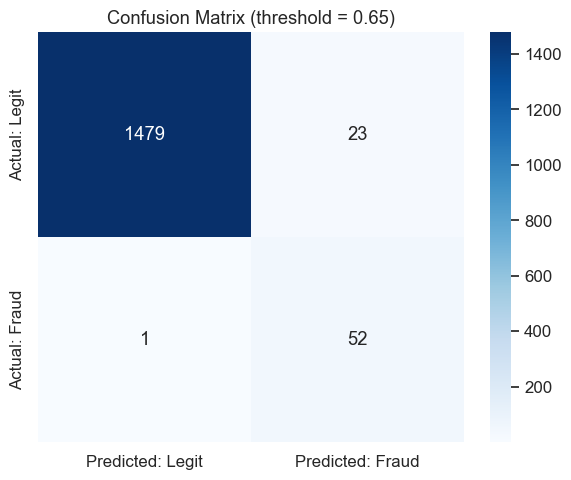

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
    yticklabels=['Actual: Legit', 'Actual: Fraud'],
    ax=ax
)
ax.set_title('Confusion Matrix (threshold = {})'.format(threshold))
plt.tight_layout()
plt.show()


## 5. Precision-Recall Curve

Shows the full precision-recall tradeoff across all thresholds.
The red dot marks the operating point at the tuned threshold.
The dashed baseline is what a random classifier achieves (equal to fraud rate).

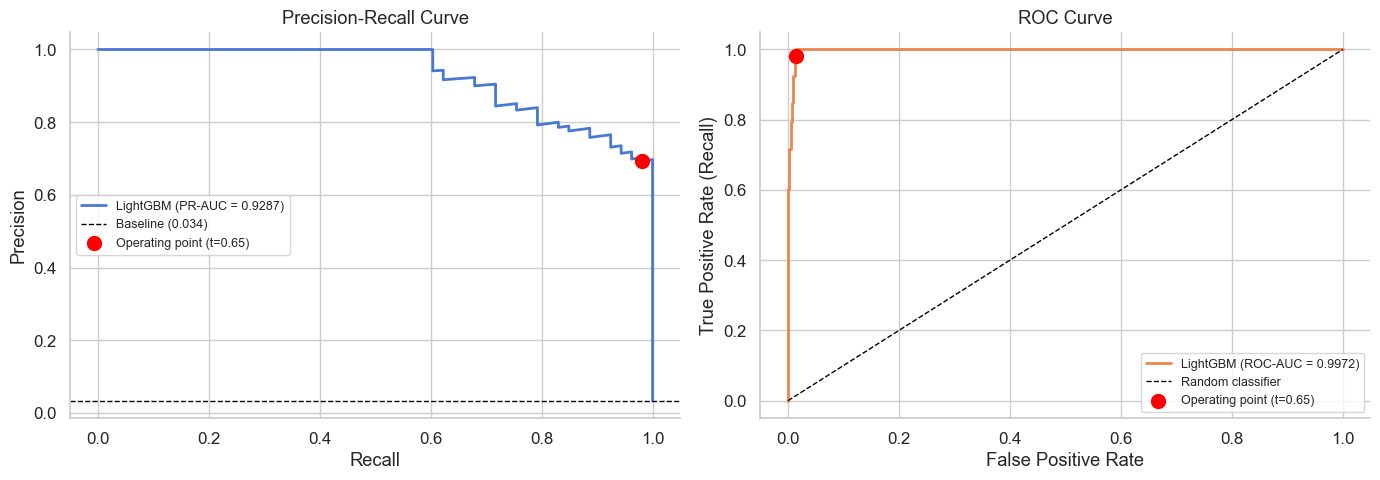

In [6]:
prec_curve, rec_curve, thresholds_curve = precision_recall_curve(y_true, y_proba)
baseline = y_true.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(rec_curve, prec_curve, color=COLORS[0], linewidth=2,
             label='LightGBM (PR-AUC = {:.4f})'.format(pr_auc))
axes[0].axhline(baseline, color='black', linestyle='--', linewidth=1,
                label='Baseline ({:.3f})'.format(baseline))
axes[0].scatter([recall], [precision], color='red', zorder=5, s=100,
                label='Operating point (t={})'.format(threshold))
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(fontsize=9)

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_proba)
axes[1].plot(fpr_curve, tpr_curve, color=COLORS[1], linewidth=2,
             label='LightGBM (ROC-AUC = {:.4f})'.format(roc_auc))
axes[1].plot([0,1],[0,1], color='black', linestyle='--', linewidth=1,
             label='Random classifier')
axes[1].scatter([fpr], [recall], color='red', zorder=5, s=100,
                label='Operating point (t={})'.format(threshold))
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()


## 6. Classification Report

Full per-class metrics including support (actual count per class).

In [ ]:
print(classification_report(
    y_true, y_pred,
    target_names=['Legitimate', 'Fraud'],
    digits=4
))


## 7. Probability Distribution

How does the model's fraud probability distribute across fraud vs legitimate?

A well-calibrated model should show clear separation —
fraud transactions clustered near 1.0, legitimate near 0.0.

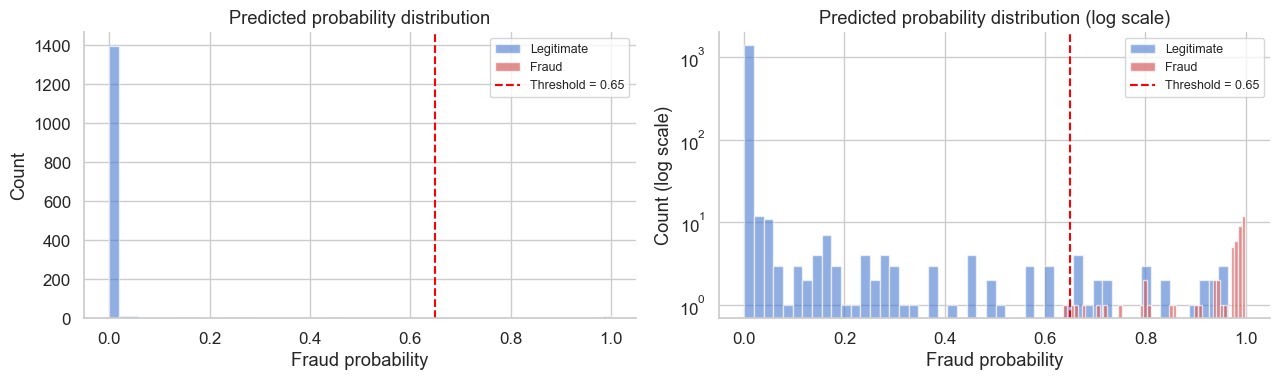

Legitimate probability stats:
count   1502.0000
mean       0.0240
std        0.1159
min        0.0001
25%        0.0001
50%        0.0001
75%        0.0002
max        0.9644

Fraud probability stats:
count   53.0000
mean     0.9206
std      0.1082
min      0.6362
25%      0.9008
50%      0.9776
75%      0.9908
max      0.9990


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overlapping histograms
axes[0].hist(results_df[results_df['is_fraud_actual']==0]['fraud_probability'],
             bins=50, alpha=0.6, color=COLORS[0], label='Legitimate', edgecolor='white')
axes[0].hist(results_df[results_df['is_fraud_actual']==1]['fraud_probability'],
             bins=50, alpha=0.7, color=COLORS[3], label='Fraud', edgecolor='white')
axes[0].axvline(threshold, color='red', linestyle='--',
                linewidth=1.5, label='Threshold = {}'.format(threshold))
axes[0].set_xlabel('Fraud probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Predicted probability distribution')
axes[0].legend(fontsize=9)

# Log scale to reveal low-probability tail
axes[1].hist(results_df[results_df['is_fraud_actual']==0]['fraud_probability'],
             bins=50, alpha=0.6, color=COLORS[0], label='Legitimate',
             edgecolor='white', log=True)
axes[1].hist(results_df[results_df['is_fraud_actual']==1]['fraud_probability'],
             bins=50, alpha=0.7, color=COLORS[3], label='Fraud',
             edgecolor='white', log=True)
axes[1].axvline(threshold, color='red', linestyle='--',
                linewidth=1.5, label='Threshold = {}'.format(threshold))
axes[1].set_xlabel('Fraud probability')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Predicted probability distribution (log scale)')
axes[1].legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

print('Legitimate probability stats:')
print(results_df[results_df['is_fraud_actual']==0]['fraud_probability'].describe().to_string())
print()
print('Fraud probability stats:')
print(results_df[results_df['is_fraud_actual']==1]['fraud_probability'].describe().to_string())


## 8. Error Analysis

Examine the transactions the model got wrong:

- **False Negatives** — fraud the model missed (highest business cost)
- **False Positives** — legitimate transactions wrongly blocked

In [8]:
features_df = pd.read_csv('../data/processed/features.csv', parse_dates=['timestamp'])

# Rebuild test set indices using same split as notebook 5
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42

X = features_df[feat_cols].fillna(-1)
y = features_df['is_fraud']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

test_features = features_df.loc[X_test.index].copy()
test_features['fraud_probability'] = y_proba.values
test_features['is_fraud_predicted'] = y_pred.values

false_negatives = test_features[
    (test_features['is_fraud']==1) & (test_features['is_fraud_predicted']==0)
]
false_positives = test_features[
    (test_features['is_fraud']==0) & (test_features['is_fraud_predicted']==1)
]

print('False Negatives: {} (fraud missed)'.format(len(false_negatives)))
print('False Positives: {} (legit wrongly flagged)'.format(len(false_positives)))


False Negatives: 1 (fraud missed)
False Positives: 23 (legit wrongly flagged)


In [9]:
# False negative analysis — what did the missed fraud look like?
if len(false_negatives) > 0:
    print('Missed fraud transactions:')
    print(false_negatives[['fraud_probability','amount','is_night',
                              'is_high_amount','location_missing',
                              'device_changed']].to_string())
else:
    print('No false negatives — model caught all fraud cases.')


Missed fraud transactions:
      fraud_probability    amount  is_night  is_high_amount  location_missing  device_changed
1916             0.6362 4006.2700         1               1                 0               1


In [10]:
# False positive analysis — what made the model suspect these legitimate transactions?
print('Top 10 false positives by fraud probability:')
fp_sorted = false_positives.nlargest(10, 'fraud_probability')
print(fp_sorted[['fraud_probability','amount','is_night','is_high_amount',
                  'location_missing','device_changed','txn_type_encoded']].to_string())


Top 10 false positives by fraud probability:
      fraud_probability    amount  is_night  is_high_amount  location_missing  device_changed  txn_type_encoded
246              0.9644 4357.6500         1               1                 0               1                 3
254              0.9607 4271.4900         1               1                 0               1                 3
5652             0.9538 4452.1500         1               1                 0               0                 2
2654             0.9449 4461.6600         0               1                 0               1                 4
2023             0.9325 4121.1300         0               1                 0               1                 0
2772             0.9152 4645.4300         1               1                 0               1                 1
1016             0.9114 4584.1800         1               1                 0               1                 4
2830             0.8972 4216.9200         1               1

## 9. Feature Importance

Extract feature importance from the trained LightGBM model.
`gain` importance measures how much each feature improves the model's
predictions when used as a split point.

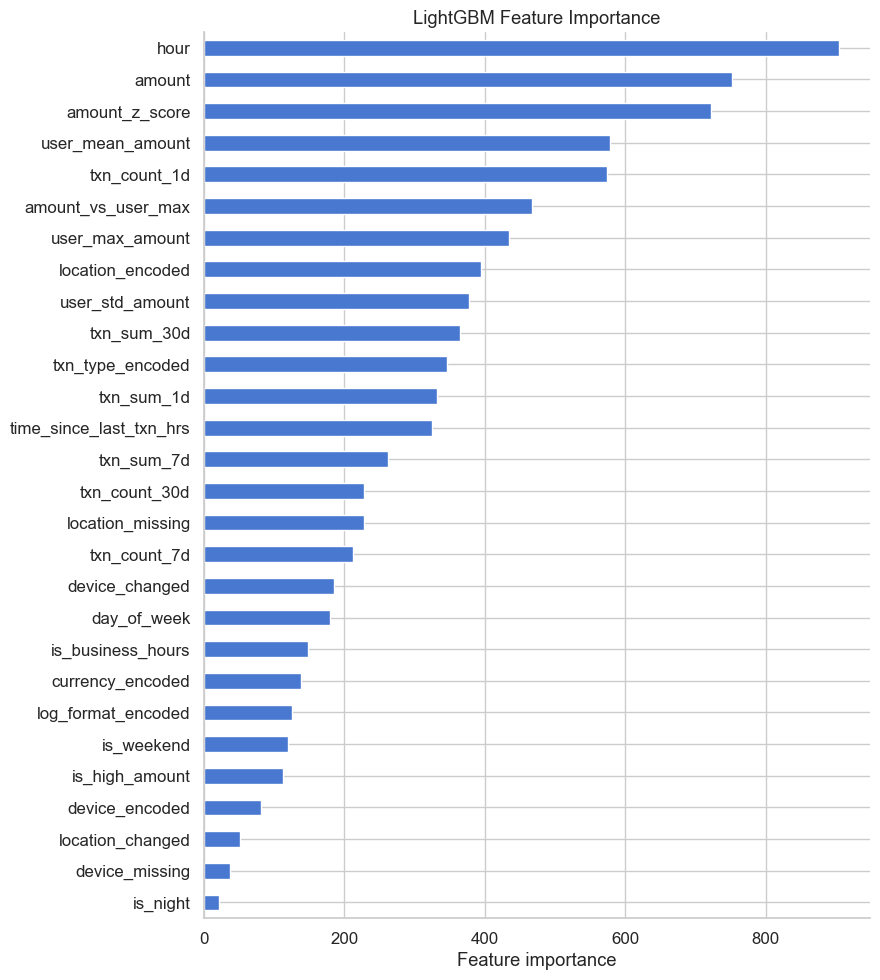

Top 10 features:
hour                  904
amount                752
amount_z_score        722
user_mean_amount      578
txn_count_1d          574
amount_vs_user_max    468
user_max_amount       435
location_encoded      395
user_std_amount       378
txn_sum_30d           365


In [11]:
import lightgbm as lgb

classifier = model.named_steps['model']

importance = pd.Series(
    classifier.feature_importances_,
    index=feat_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
importance.plot.barh(ax=ax, color=COLORS[0], edgecolor='white')
ax.set_xlabel('Feature importance')
ax.set_title('LightGBM Feature Importance')
sns.despine()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance.sort_values(ascending=False).head(10).to_string())


## 10. SHAP Analysis

SHAP (SHapley Additive exPlanations) explains individual predictions.

Unlike feature importance (which is global), SHAP shows exactly how much
each feature pushed a specific transaction toward or away from fraud.


In [12]:
import shap

X_test_df = pd.DataFrame(results_df[feat_cols].values, columns=feat_cols)

# TreeExplainer is fast for LightGBM and XGBoost
explainer   = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_df)

# For binary classification LightGBM returns a list - take class 1 (fraud)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('SHAP values shape:', sv.shape)


SHAP values shape: (1555, 28)


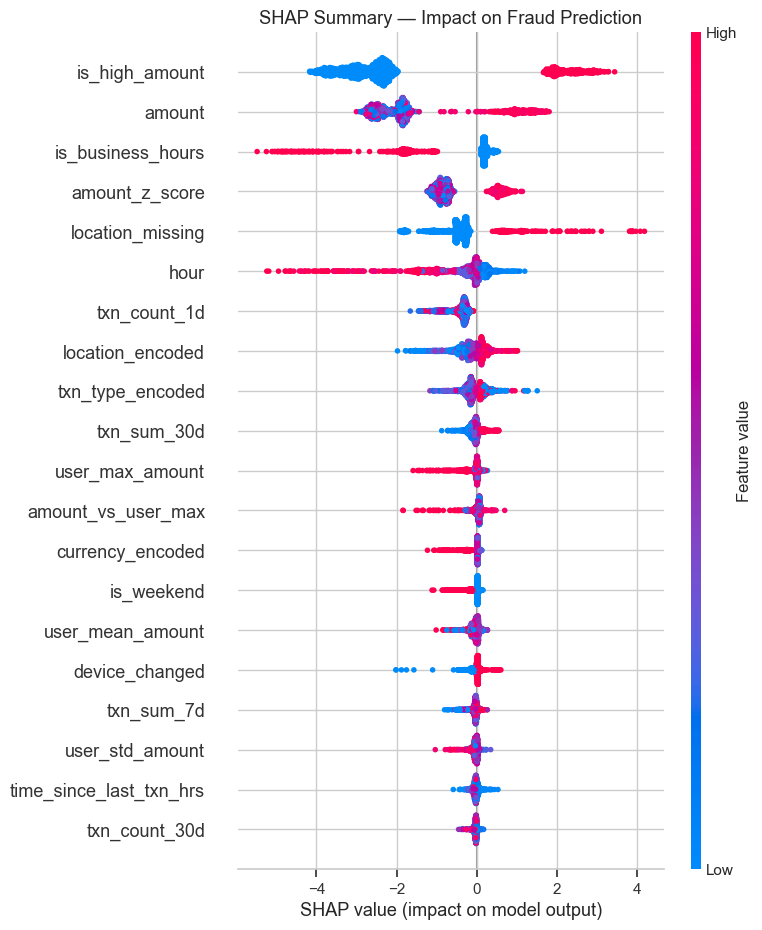

In [13]:
# Global SHAP summary — beeswarm plot
# Each dot is one transaction. Red = high feature value, Blue = low.
# X-axis shows the impact on fraud probability.
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test_df, show=False)
plt.title('SHAP Summary — Impact on Fraud Prediction')
plt.tight_layout()
plt.show()


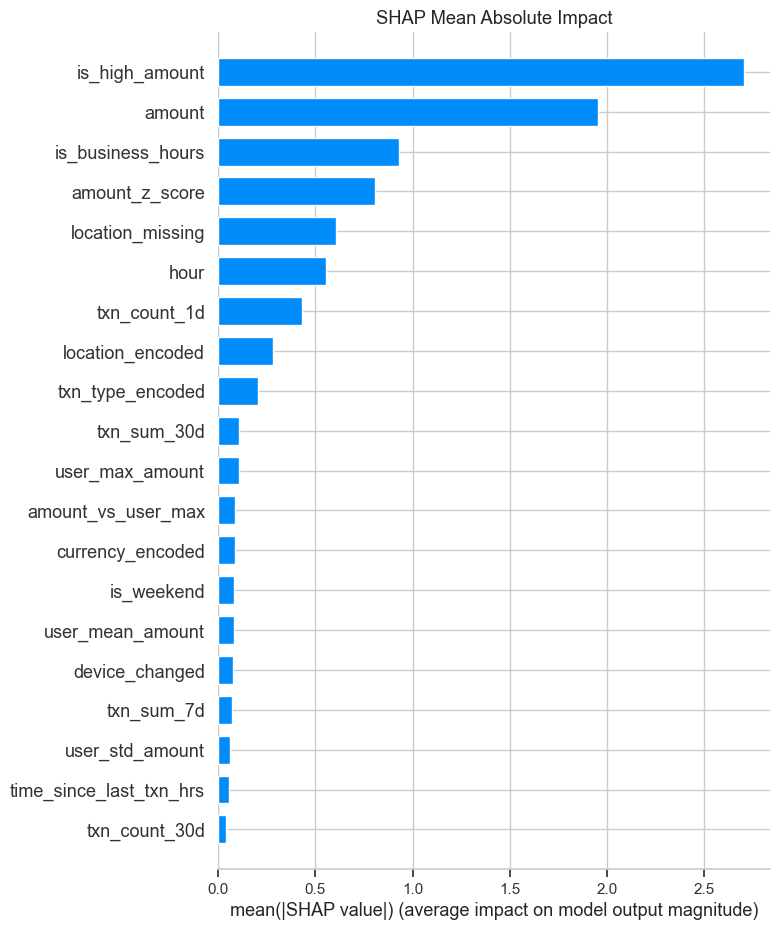

In [14]:
# SHAP bar plot — mean absolute impact per feature
plt.figure(figsize=(9, 8))
shap.summary_plot(sv, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Mean Absolute Impact')
plt.tight_layout()
plt.show()


In [15]:
# Explain one fraud prediction in detail
# Pick the highest-probability fraud case
fraud_indices = results_df[results_df['is_fraud_actual']==1].index
top_fraud_idx = results_df.loc[fraud_indices, 'fraud_probability'].idxmax()

print('Explaining highest-confidence fraud prediction:')
print('  fraud_probability : {:.4f}'.format(results_df.loc[top_fraud_idx, 'fraud_probability']))
print('  amount            : {:.2f}'.format(results_df.loc[top_fraud_idx, 'amount']))
print('  is_night          : {}'.format(int(results_df.loc[top_fraud_idx, 'is_night'])))
print('  is_high_amount    : {}'.format(int(results_df.loc[top_fraud_idx, 'is_high_amount'])))
print('  location_missing  : {}'.format(int(results_df.loc[top_fraud_idx, 'location_missing'])))
print()

shap_row = pd.Series(sv[top_fraud_idx], index=feat_cols)
top_contributors = shap_row.abs().sort_values(ascending=False).head(8).index

print('Top SHAP contributors for this prediction:')
for feat in top_contributors:
    direction = 'fraud' if shap_row[feat] > 0 else 'legit'
    print('  {:<30}: {:.4f}  -> pushes toward {}'.format(
        feat, shap_row[feat], direction))


Explaining highest-confidence fraud prediction:
  fraud_probability : 0.9990
  amount            : 4578.07
  is_night          : 1
  is_high_amount    : 1
  location_missing  : 1

Top SHAP contributors for this prediction:
  is_high_amount                : 3.2777  -> pushes toward fraud
  amount                        : 1.7060  -> pushes toward fraud
  location_missing              : 1.1596  -> pushes toward fraud
  amount_z_score                : 0.9590  -> pushes toward fraud
  txn_count_1d                  : -0.6463  -> pushes toward legit
  txn_type_encoded              : 0.5988  -> pushes toward fraud
  hour                          : 0.3113  -> pushes toward fraud
  location_encoded              : 0.2738  -> pushes toward fraud


## 11. Business Impact Summary

Translate model metrics into business terms.
Assumptions (adjust to your context):
- Average fraud transaction value: mean amount of fraud cases in test set
- Cost of false alarm (customer friction + investigation): 5% of transaction value
- Cost of missed fraud: full transaction value lost

In [16]:
fraud_test = results_df[results_df['is_fraud_actual']==1]
avg_fraud_value = fraud_test['amount'].mean() if 'amount' in fraud_test.columns \
                  else features_df.loc[X_test.index][y_test==1]['amount'].mean()

# Rebuild amount series for test set
test_amounts = features_df.loc[X_test.index, 'amount'].values
fraud_mask   = y_test.values == 1
pred_mask    = y_pred.values == 1

avg_fraud_val = test_amounts[fraud_mask].mean()
fp_cost_rate  = 0.05

# Value protected: fraud we caught
value_protected = test_amounts[fraud_mask & pred_mask].sum()

# Value lost: fraud we missed
value_lost = test_amounts[fraud_mask & ~pred_mask].sum()

# Cost of false alarms
fp_amounts = test_amounts[~fraud_mask & pred_mask]
fa_cost    = fp_amounts.sum() * fp_cost_rate

# Net benefit
net_benefit = value_protected - value_lost - fa_cost

print('=' * 55)
print('  BUSINESS IMPACT SUMMARY')
print('=' * 55)
print('  Fraud cases in test set    : {}'.format(int(fraud_mask.sum())))
print('  Avg fraud transaction value: {:.2f}'.format(avg_fraud_val))
print()
print('  Fraud caught (TP)          : {}'.format(tp))
print('  Value protected            : {:.2f}'.format(value_protected))
print()
print('  Fraud missed (FN)          : {}'.format(fn))
print('  Value lost                 : {:.2f}'.format(value_lost))
print()
print('  False alarms (FP)          : {}'.format(fp))
print('  False alarm cost (5% rate) : {:.2f}'.format(fa_cost))
print()
print('  Net benefit                : {:.2f}'.format(net_benefit))
print('=' * 55)


  BUSINESS IMPACT SUMMARY
  Fraud cases in test set    : 53
  Avg fraud transaction value: 4429.46

  Fraud caught (TP)          : 52
  Value protected            : 230755.06

  Fraud missed (FN)          : 1
  Value lost                 : 4006.27

  False alarms (FP)          : 23
  False alarm cost (5% rate) : 5022.32

  Net benefit                : 221726.47


## 12. Final Summary

Complete model card for FraudShield V2.

In [17]:
print('=' * 55)
print('  FRAUDSHIELD V2 — MODEL CARD')
print('=' * 55)
print('  Algorithm    : LightGBM + ADASYN')
print('  Threshold    : {}'.format(threshold))
print()
print('  Performance')
print('  PR-AUC   : {:.4f}'.format(pr_auc))
print('  ROC-AUC  : {:.4f}'.format(roc_auc))
print('  F1       : {:.4f}'.format(f1))
print('  Recall   : {:.4f}  ({} / {} fraud cases caught)'.format(
    recall, tp, tp+fn))
print('  Precision: {:.4f}  ({} false alarms per {} flags)'.format(
    precision, fp, tp+fp))
print('  FPR      : {:.4f}  ({} legit blocked per {} legit)'.format(
    fpr, fp, tn+fp))
print()
print('  Label simulation')
print('  Method   : Deterministic rule-based')
print('  Rules    : 3 conjunctive signal combinations')
print('  Fraud rate: {:.1f}%'.format(y_true.mean()*100))
print()
print('  Training data')
print('  Raw logs : 10,000 rows (7 formats)')
print('  Parsed   : 7,774 rows')
print('  Features : {} engineered'.format(len(feat_cols)))
print('=' * 55)


  FRAUDSHIELD V2 — MODEL CARD
  Algorithm    : LightGBM + ADASYN
  Threshold    : 0.65

  Performance
  PR-AUC   : 0.9287
  ROC-AUC  : 0.9972
  F1       : 0.8125
  Recall   : 0.9811  (52 / 53 fraud cases caught)
  Precision: 0.6933  (23 false alarms per 75 flags)
  FPR      : 0.0153  (23 legit blocked per 1502 legit)

  Label simulation
  Method   : Deterministic rule-based
  Rules    : 3 conjunctive signal combinations
  Fraud rate: 3.4%

  Training data
  Raw logs : 10,000 rows (7 formats)
  Parsed   : 7,774 rows
  Features : 28 engineered
